In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score


In [192]:
df=pd.read_csv("/content/new_insurance_data (1).csv")
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [193]:
df.shape


(1338, 13)

In [194]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [195]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [196]:
df.isnull()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False,False,False,False,False,False,False


In [197]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [198]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


In [199]:
a = df["age"].mean()
a



np.float64(39.31000752445448)

In [200]:
b= df["age"].median()
b

39.0

In [201]:
c=df["smoker"].mode()[0]
c

'no'

In [202]:
col=df.columns
col

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [203]:
col=list(col)
col

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary',
 'region',
 'charges']

In [204]:
for col_name in col:
  if df[col_name].dtype=='object':
    df[col_name]=df[col_name].fillna(df[col_name].mode()[0])
  else:
    df[col_name]=df[col_name].fillna(df[col_name].mean())



In [205]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


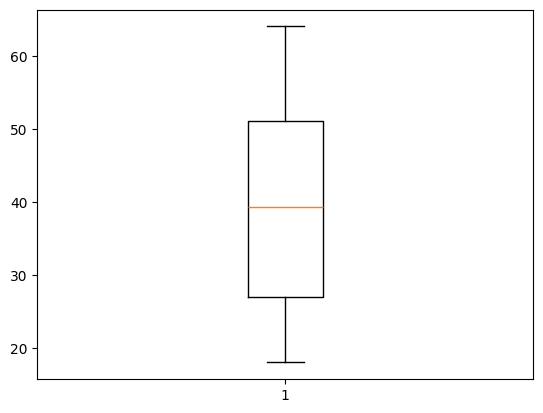

In [206]:
plt.boxplot(df["age"])
plt.show()

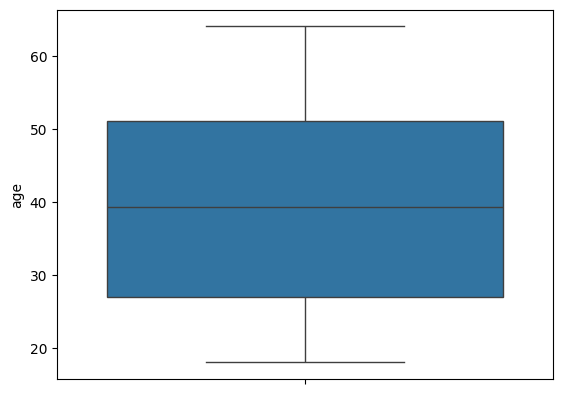

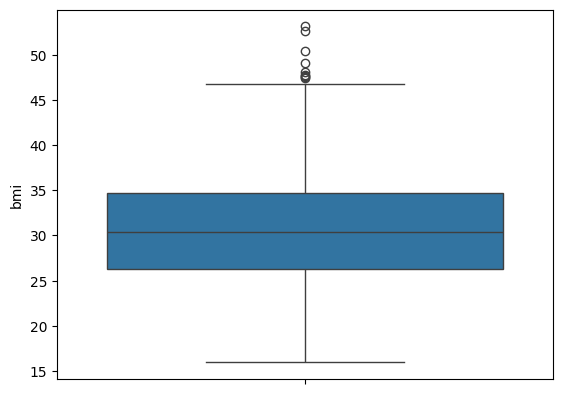

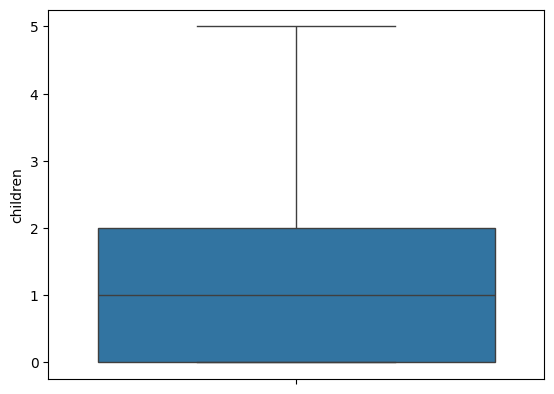

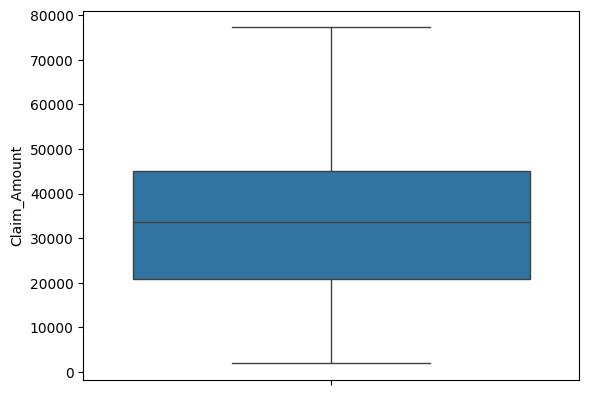

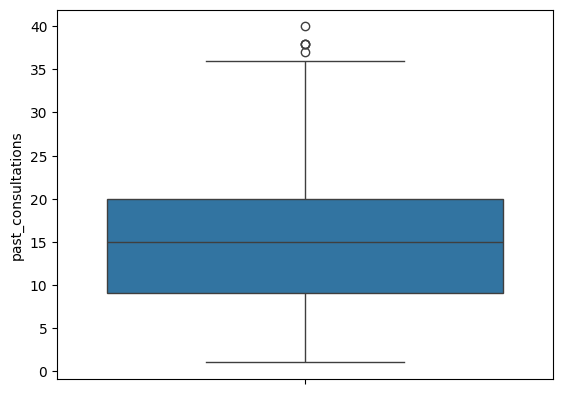

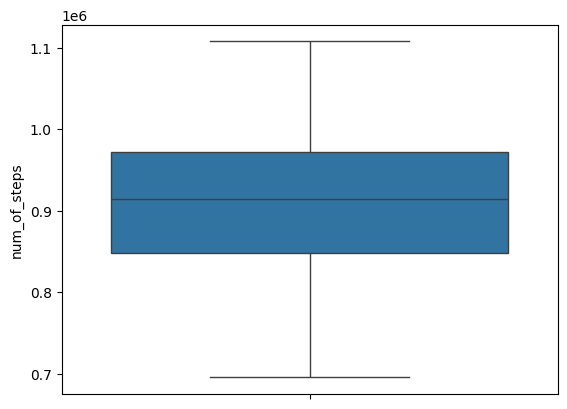

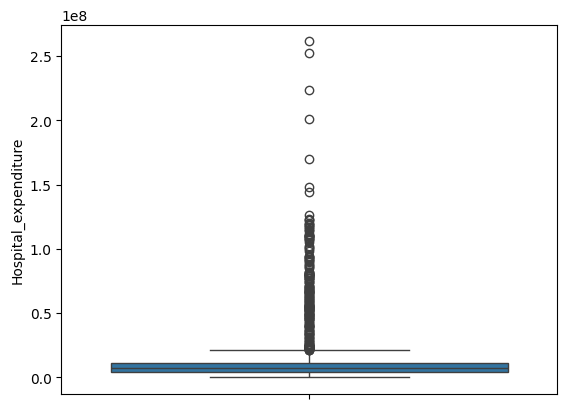

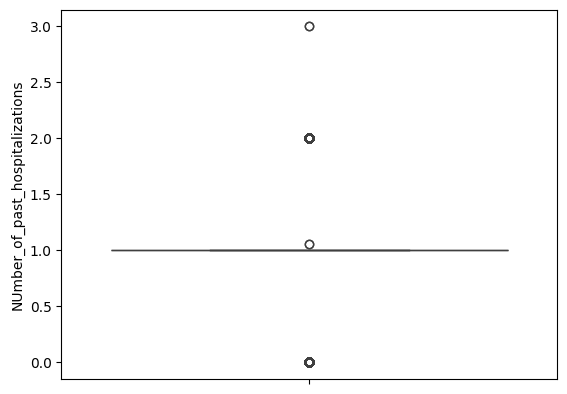

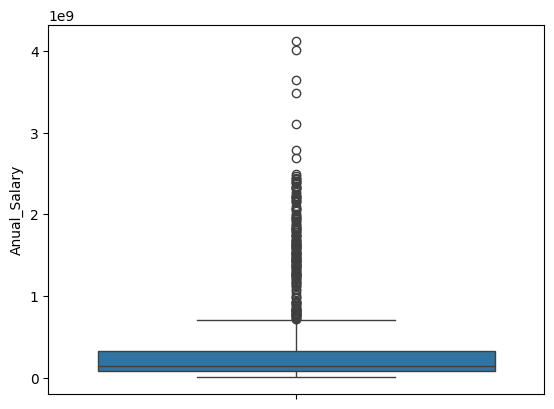

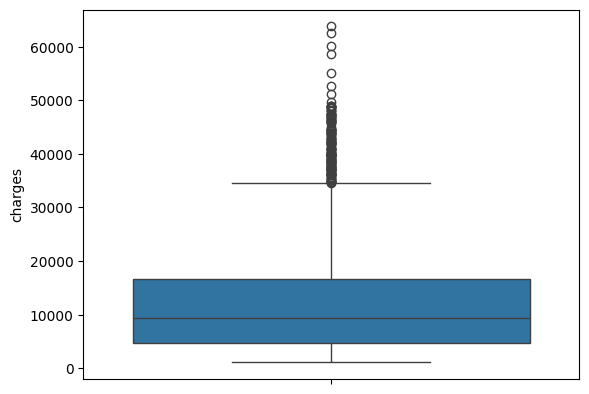

In [207]:



col = df.columns

for col_name in col:
    if df[col_name].dtype != 'object':
        sns.boxplot(df[col_name])
        plt.show()

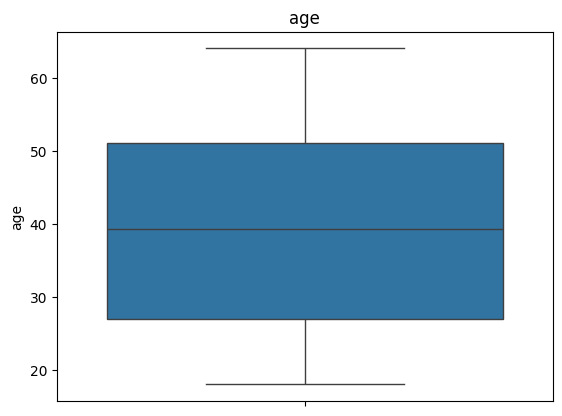

age
Q1: 27.0
Q3: 51.0
IQR: 24.0
Lower: -9.0
Upper: 87.0

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25.0   
1336  45.0    male  30.360       0.0    yes   69927.51664                34.0   
1337  54.0  female  47.410       0.0    yes   63982.

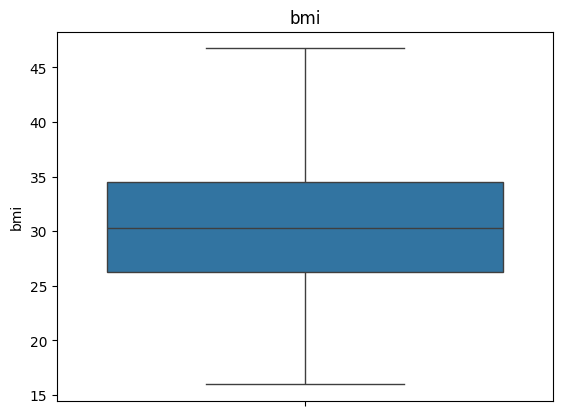

bmi
Q1: 26.315
Q3: 34.65625
IQR: 8.341249999999999
Lower: 13.803125000000003
Upper: 47.168124999999996

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1332  60.0    male  32.800       0.0    yes   77277.98848                40.0   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25.0   
1336 

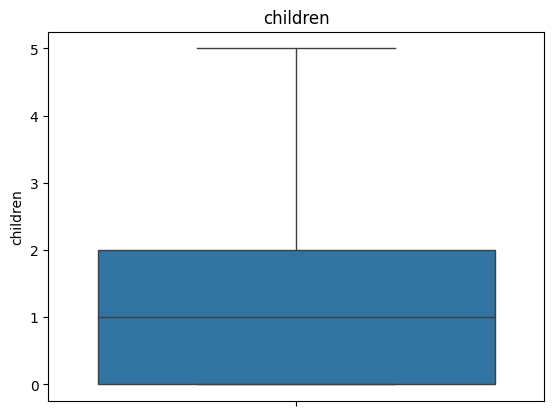

children
Q1: 0.0
Q3: 2.0
IQR: 2.0
Lower: -3.0
Upper: 5.0

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1332  60.0    male  32.800       0.0    yes   77277.98848                40.0   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25.0   
1336  45.0    male  30.360       0.0    yes   69927

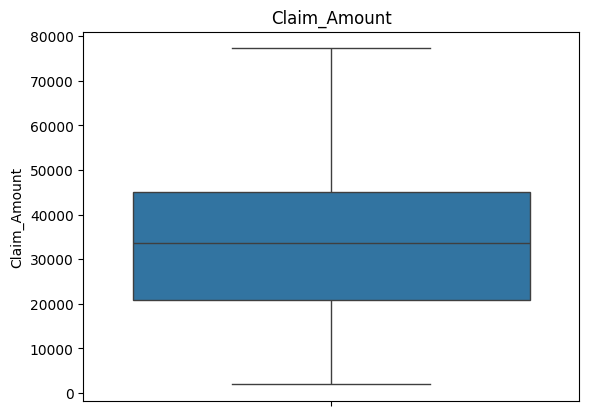

Claim_Amount
Q1: 20946.99765
Q3: 44964.91667
IQR: 24017.919019999998
Lower: -15079.880879999993
Upper: 80991.7952

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1332  60.0    male  32.800       0.0    yes   77277.98848                40.0   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25

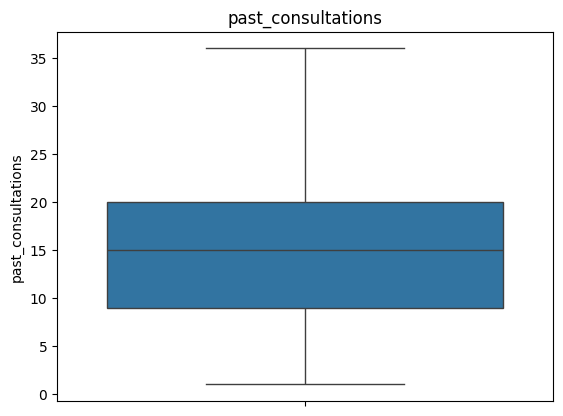

past_consultations
Q1: 9.0
Q3: 20.0
IQR: 11.0
Lower: -7.5
Upper: 36.5

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1331  28.0    male  36.400       1.0    yes   55590.75527                26.0   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25.0   
1336  45.0    male  30.360       0.0  

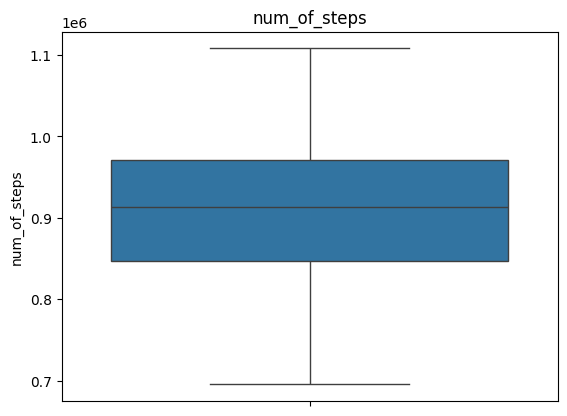

num_of_steps
Q1: 847029.5
Q3: 970315.75
IQR: 123286.25
Lower: 662100.125
Upper: 1155245.125

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1331  28.0    male  36.400       1.0    yes   55590.75527                26.0   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25.0   
1336  45.0    ma

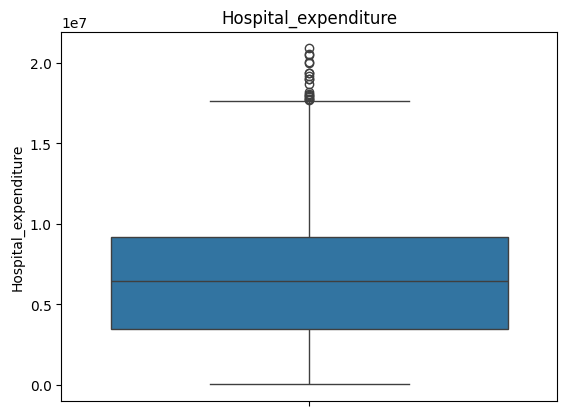

Hospital_expenditure
Q1: 4057600.2785
Q3: 10806883.51
IQR: 6749283.2315
Lower: -6066324.56875
Upper: 20930808.357249998

       age     sex    bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.21       0.0     no   29087.54313                17.0   
1     18.0    male  30.14       0.0     no   39053.67437                 7.0   
2     18.0    male  33.33       0.0     no   39023.62759                19.0   
3     18.0    male  33.66       0.0     no   28185.39332                11.0   
4     18.0    male  34.10       0.0     no   14697.85941                16.0   
...    ...     ...    ...       ...    ...           ...                 ...   
1142  50.0  female  27.36       0.0     no   36320.75384                16.0   
1144  52.0    male  26.40       3.0     no   53738.44070                12.0   
1145  21.0  female  32.68       2.0     no   65600.22548                25.0   
1149  47.0  female  24.10       1.0     no   48323.47052                25.0   

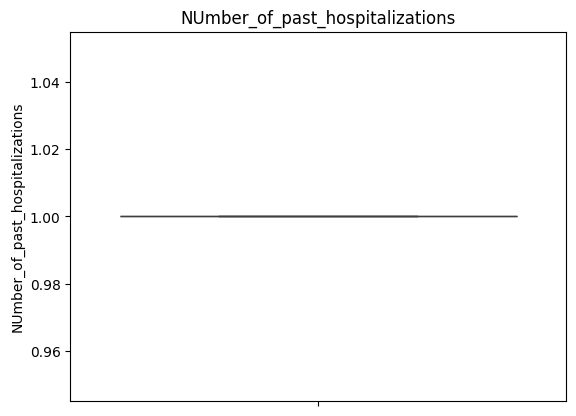

NUmber_of_past_hospitalizations
Q1: 1.0
Q3: 1.0
IQR: 0.0
Lower: 1.0
Upper: 1.0

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
151   25.0    male  27.550       0.0     no   39148.95495                10.0   
152   22.0  female  20.235       0.0     no   41547.52536                13.0   
153   25.0    male  35.625       0.0     no   39660.60193                12.0   
154   20.0    male  31.130       2.0     no   16032.87148                 7.0   
155   21.0  female  17.400       1.0     no   31090.98977                21.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1102  40.0  female  28.120       1.0    yes   39243.68660                22.0   
1103  23.0  female  24.225       2.0     no   16745.56410                18.0   
1105  39.0    male  29.925       1.0    yes   49708.65168                24.0   
1106  43.0  female  26.700       2.0    yes   18777.25866                28.0   
1107  19.0    male  27.265   

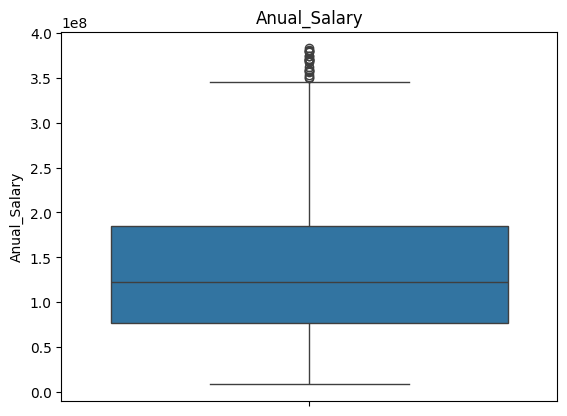

Anual_Salary
Q1: 81847331.8475
Q3: 202807023.65
IQR: 120959691.80250001
Lower: -99592205.85625002
Upper: 384246561.35375

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
151   25.0    male  27.550       0.0     no   39148.95495                10.0   
152   22.0  female  20.235       0.0     no   41547.52536                13.0   
153   25.0    male  35.625       0.0     no   39660.60193                12.0   
154   20.0    male  31.130       2.0     no   16032.87148                 7.0   
155   21.0  female  17.400       1.0     no   31090.98977                21.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1046  29.0  female  27.940       1.0    yes   51168.25474                23.0   
1048  31.0    male  25.900       3.0    yes   46619.40230                27.0   
1050  31.0    male  29.810       0.0    yes   24382.58056                21.0   
1062  43.0  female  20.045       2.0    yes   21596.43846           

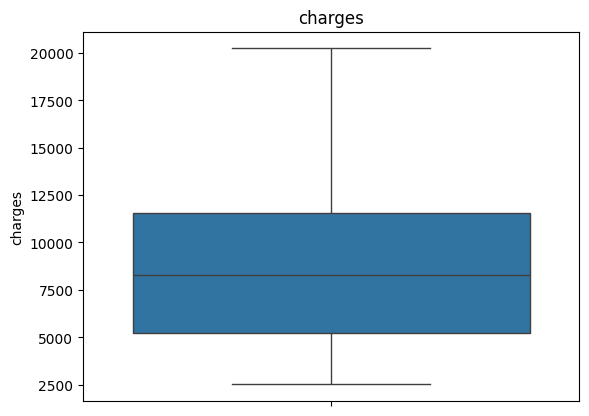

charges
Q1: 5209.57885
Q3: 11566.30055
IQR: 6356.7217
Lower: -4325.503699999999
Upper: 21101.3831

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
151   25.0    male  27.550       0.0     no   39148.95495                10.0   
152   22.0  female  20.235       0.0     no   41547.52536                13.0   
153   25.0    male  35.625       0.0     no   39660.60193                12.0   
154   20.0    male  31.130       2.0     no   16032.87148                 7.0   
155   21.0  female  17.400       1.0     no   31090.98977                21.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1046  29.0  female  27.940       1.0    yes   51168.25474                23.0   
1048  31.0    male  25.900       3.0    yes   46619.40230                27.0   
1050  31.0    male  29.810       0.0    yes   24382.58056                21.0   
1062  43.0  female  20.045       2.0    yes   21596.43846                10.0   
1069  35.0

In [208]:
for col_name in col:
    if df[col_name].dtype != "object" :
        Q1 = df[col_name].quantile(0.25)
        Q3 = df[col_name].quantile(0.75)

        IQR = Q3 - Q1

        LB = Q1 - 1.5 * IQR
        UB = Q3 + 1.5 * IQR

        df = df[(df[col_name] >= LB) & (df[col_name] <= UB)]

        sns.boxplot(df[col_name])
        plt.title(col_name)
        plt.show()


    print(col_name)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", LB)
    print("Upper:", UB)
    print()
    print(df)

In [209]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [210]:
col_list = []

for col in df.columns:
    if df[col].dtype != 'object' and col != 'charges':
        col_list.append(col)

col_list

['age',
 'bmi',
 'children',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary']

In [211]:
x=df[col_list]
print(x)

       age     bmi  children  Claim_Amount  past_consultations  num_of_steps  \
151   25.0  27.550       0.0   39148.95495                10.0      780652.0   
152   22.0  20.235       0.0   41547.52536                13.0      802627.0   
153   25.0  35.625       0.0   39660.60193                12.0      770773.0   
154   20.0  31.130       2.0   16032.87148                 7.0      769255.0   
155   21.0  17.400       1.0   31090.98977                21.0      778769.0   
...    ...     ...       ...           ...                 ...           ...   
1046  29.0  27.940       1.0   51168.25474                23.0      993751.0   
1048  31.0  25.900       3.0   46619.40230                27.0      989387.0   
1050  31.0  29.810       0.0   24382.58056                21.0      973924.0   
1062  43.0  20.045       2.0   21596.43846                10.0      994419.0   
1069  35.0  28.025       0.0   17200.14586                15.0      993979.0   

      Hospital_expenditure  NUmber_of_p

In [212]:
vif_data=pd.DataFrame()
vif_data["feature"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_data


,feature,VIF
0,age,2.196194
1,bmi,1.052717
2,children,1.076523
3,Claim_Amount,1.035033
4,past_consultations,1.073989
5,num_of_steps,5.882074
6,Hospital_expenditure,1.173208
7,NUmber_of_past_hospitalizations,1.000000
8,Anual_Salary,3.983678


In [213]:
df = df.drop('num_of_steps', axis=1)

In [214]:
vif_data=pd.DataFrame()
vif_data["feature"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_data


,feature,VIF
0,age,2.196194
1,bmi,1.052717
2,children,1.076523
3,Claim_Amount,1.035033
4,past_consultations,1.073989
5,num_of_steps,5.882074
6,Hospital_expenditure,1.173208
7,NUmber_of_past_hospitalizations,1.000000
8,Anual_Salary,3.983678


In [215]:
df = df.drop(columns=['num_of_steps'], errors='ignore')
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,male,27.550,0.0,no,39148.95495,10.0,8.614147e+06,1.0,5.452601e+07,northwest,2523.16950
152,22.0,female,20.235,0.0,no,41547.52536,13.0,2.491594e+05,1.0,1.671847e+07,northwest,2527.81865
153,25.0,male,35.625,0.0,no,39660.60193,12.0,3.043323e+06,1.0,4.852694e+07,northwest,2534.39375
154,20.0,male,31.130,2.0,no,16032.87148,7.0,1.599069e+06,1.0,2.441262e+07,southeast,2566.47070
155,21.0,female,17.400,1.0,no,31090.98977,21.0,3.015365e+06,1.0,5.853579e+07,southwest,2585.26900
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.900,3.0,yes,46619.40230,27.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [216]:
vif_data=pd.DataFrame()
vif_data["feature"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_data

,feature,VIF
0,age,2.196194
1,bmi,1.052717
2,children,1.076523
3,Claim_Amount,1.035033
4,past_consultations,1.073989
5,num_of_steps,5.882074
6,Hospital_expenditure,1.173208
7,NUmber_of_past_hospitalizations,1.000000
8,Anual_Salary,3.983678


In [217]:
col_list = []
for col in df.columns:
  if((df[col].dtype != 'object')&(col != 'charges')):
    col_list.append(col)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                           feature       VIF
0                              age  1.273600
1                              bmi  1.046387
2                         children  1.026493
3                     Claim_Amount  1.020827
4               past_consultations  1.068339
5             Hospital_expenditure  1.167493
6  NUmber_of_past_hospitalizations  1.000000
7                     Anual_Salary  1.453461


In [218]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,male,27.550,0.0,no,39148.95495,10.0,8.614147e+06,1.0,5.452601e+07,northwest,2523.16950
152,22.0,female,20.235,0.0,no,41547.52536,13.0,2.491594e+05,1.0,1.671847e+07,northwest,2527.81865
153,25.0,male,35.625,0.0,no,39660.60193,12.0,3.043323e+06,1.0,4.852694e+07,northwest,2534.39375
154,20.0,male,31.130,2.0,no,16032.87148,7.0,1.599069e+06,1.0,2.441262e+07,southeast,2566.47070
155,21.0,female,17.400,1.0,no,31090.98977,21.0,3.015365e+06,1.0,5.853579e+07,southwest,2585.26900
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.900,3.0,yes,46619.40230,27.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [219]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,male,27.550,0.0,no,39148.95495,10.0,8.614147e+06,1.0,5.452601e+07,northwest,2523.16950
152,22.0,female,20.235,0.0,no,41547.52536,13.0,2.491594e+05,1.0,1.671847e+07,northwest,2527.81865
153,25.0,male,35.625,0.0,no,39660.60193,12.0,3.043323e+06,1.0,4.852694e+07,northwest,2534.39375
154,20.0,male,31.130,2.0,no,16032.87148,7.0,1.599069e+06,1.0,2.441262e+07,southeast,2566.47070
155,21.0,female,17.400,1.0,no,31090.98977,21.0,3.015365e+06,1.0,5.853579e+07,southwest,2585.26900
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.900,3.0,yes,46619.40230,27.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [220]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [221]:
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i])


In [222]:
print(df)

       age  sex     bmi  children  smoker  Claim_Amount  past_consultations  \
151   25.0    1  27.550       0.0       0   39148.95495                10.0   
152   22.0    0  20.235       0.0       0   41547.52536                13.0   
153   25.0    1  35.625       0.0       0   39660.60193                12.0   
154   20.0    1  31.130       2.0       0   16032.87148                 7.0   
155   21.0    0  17.400       1.0       0   31090.98977                21.0   
...    ...  ...     ...       ...     ...           ...                 ...   
1046  29.0    0  27.940       1.0       1   51168.25474                23.0   
1048  31.0    1  25.900       3.0       1   46619.40230                27.0   
1050  31.0    1  29.810       0.0       1   24382.58056                21.0   
1062  43.0    0  20.045       2.0       1   21596.43846                10.0   
1069  35.0    0  28.025       0.0       1   17200.14586                15.0   

      Hospital_expenditure  NUmber_of_past_hospital

In [228]:
x=df.iloc[:,0: 11]
print(x)

       age  sex     bmi  children  smoker  Claim_Amount  past_consultations  \
151   25.0    1  27.550       0.0       0   39148.95495                10.0   
152   22.0    0  20.235       0.0       0   41547.52536                13.0   
153   25.0    1  35.625       0.0       0   39660.60193                12.0   
154   20.0    1  31.130       2.0       0   16032.87148                 7.0   
155   21.0    0  17.400       1.0       0   31090.98977                21.0   
...    ...  ...     ...       ...     ...           ...                 ...   
1046  29.0    0  27.940       1.0       1   51168.25474                23.0   
1048  31.0    1  25.900       3.0       1   46619.40230                27.0   
1050  31.0    1  29.810       0.0       1   24382.58056                21.0   
1062  43.0    0  20.045       2.0       1   21596.43846                10.0   
1069  35.0    0  28.025       0.0       1   17200.14586                15.0   

      Hospital_expenditure  NUmber_of_past_hospital

In [229]:
y=df.iloc[:,-1]
print(y)

151      2523.16950
152      2527.81865
153      2534.39375
154      2566.47070
155      2585.26900
           ...     
1046    19107.77960
1048    19199.94400
1050    19350.36890
1062    19798.05455
1069    20234.85475
Name: charges, Length: 881, dtype: float64


In [230]:
from sklearn.model_selection import train_test_split

In [231]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=0)
x_train,x_test,y_train,y_test
print(x_train, x_test, y_train, y_test)

      age  sex     bmi  children  smoker  Claim_Amount  past_consultations  \
373  35.0    0  31.000       1.0       0   47511.14927                15.0   
351  34.0    1  25.270       1.0       0   35692.37968                15.0   
313  25.0    1  33.660       4.0       0   42330.32386                 3.0   
730  54.0    0  31.240       0.0       0   55821.53246                17.0   
996  20.0    1  27.300       0.0       1   32076.78940                21.0   
..    ...  ...     ...       ...     ...           ...                 ...   
990  38.0    1  19.300       0.0       1   47093.96209                 8.0   
343  27.0    1  18.905       3.0       0   33361.32718                11.0   
783  56.0    1  25.935       0.0       0   41899.68772                20.0   
713  53.0    1  21.400       1.0       0   44031.97502                12.0   
839  18.0    1  21.780       2.0       0   40086.75830                22.0   

     Hospital_expenditure  NUmber_of_past_hospitalizations  Anu

In [232]:
from sklearn.linear_model import LinearRegression

In [233]:
LR = LinearRegression()

In [235]:
LR.fit(x_train,y_train)

LinearRegression()

In [236]:
y_pred=LR.predict(x_test)
y_pred

array([ 4052.99198777,  7709.17355029, 10012.03288864,  3574.97120235,
       11064.58584345, 12240.87029553, 14307.59487335, 17471.81079599,
        9329.00550567,  4790.02141631,  6038.76821529,  8688.79229205,
        6254.11231456, 15650.43147816,  9365.06122919, 11588.1353577 ,
        6344.18433298,  4525.01652241,  3343.22109947,  6016.56672815,
       12444.99334094,  3965.85604014,  5880.80968452,  5583.65066022,
       10442.2980894 ,  2602.90306042, 10406.57141608,  6065.89406823,
       12450.04295197,  9388.38646087, 17938.52455571, 12204.1836653 ,
       19862.1927083 ,  8555.05192754, 10253.06225016, 12655.84314835,
        7430.42353092,  5600.84303453,  7591.71391004,  6720.52260223,
       10740.56640916, 10567.11908632,  5616.72493116, 10649.9919755 ,
        5404.4122554 ,  5654.76550503, 16174.47701712,  8963.5785816 ,
       11464.04729601, 12864.11201368,  3980.2773217 ,  5495.51301473,
        7504.92333823, 13445.28817376,  5758.40886725, 14588.71701716,
      

In [237]:
from sklearn.metrics import *
r2_score(y_test,y_pred)

0.9168861576162588

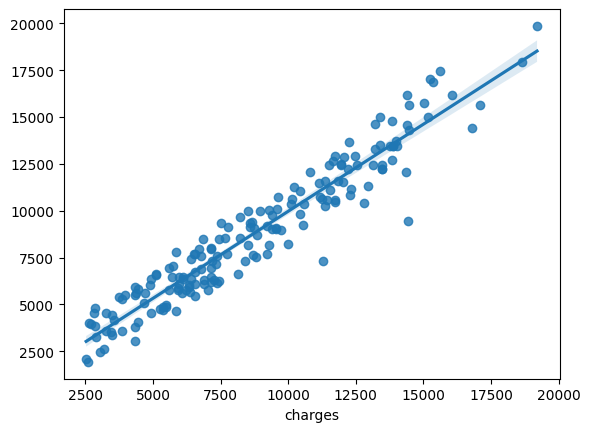

In [239]:
sns.regplot(x=y_test,y=y_pred)
plt.show()